# Homework 4: Optional Final Project (A+ Grade Bump)

- This homework template guides you through presenting your final project analysis.
- Use this notebook to:
    - Generate all visualizations/results and report findings with a pipeline then simply view the results here
    - Generate figures/analysis with imported scripts to produce visualizations/results, and report findings.

> **Note for Beginners:** Running modular Python scripts from inside a Jupyter notebook can sometimes lead to import path or dependency issues if the working directory changes. If you encounter import errors, make sure you add the path of your script folder to `sys.path`, or execute your pipeline directly from your terminal using:
```bash
uv run python src/final_project/katsuhiro-kita/pipeline.py
```

## A. Describe Project

### **Guidance**
- State the policy question, puzzle, or social science problem you are addressing.
- Frame your central hypothesis and the expected relationship between your variables.
- Describe the scope of your analysis (e.g., geographical regions, years covered).
- Highlight the datasets you selected to examine this question.

### **Project Summary**
- **Project Title:** Does Geopolitical Risk Predict Future Financial Market Stress? A Lead-Lag Analysis
- **Student Name:** Katsuhiro Kita
- **Policy Relevance Statement:** If geopolitical risk shocks reliably precede rises in financial market stress, the Geopolitical Risk (GPR) Index could serve as an early-warning indicator for central banks and financial regulators monitoring systemic credit risk.
- **Central Hypothesis:** Higher geopolitical risk today predicts higher financial market stress (corporate credit spreads) in subsequent months, i.e. the relationship is not merely contemporaneous but reflects a lead-lag (predictive) dynamic running from geopolitical risk to market stress.

### **Background: Building on HW3**
- In HW3, I merged the monthly Geopolitical Risk (GPR) Index with the Gilchrist-Zakrajšek (GZ) credit spread / Excess Bond Premium (EBP) dataset and found a contemporaneous relationship between the two series, but flagged a concern about reverse causality (does market stress drive GPR, rather than the other way around?).
- HW4 extends this by explicitly testing the lead-lag structure: does past geopolitical risk predict *current* market stress, after controlling for the fact that market stress is highly persistent (autocorrelated) month to month? I also test the reverse direction (does past market stress predict current GPR?) as a robustness/falsification check.

---

## 1. Download Data

### **Guidance**
- Run the data acquisition step by executing or importing from your `data.py` file.
- Ensure your script programmatically downloads the datasets and saves them locally.
- Verify the download by displaying the destination folder structure and confirming files are saved.

### **Data Acquisition Details**
- **Primary Data Source:** Geopolitical Risk (GPR) Index, Caldara & Iacoviello (monthly, 1900-present) — https://www.matteoiacoviello.com/gpr.htm
- **Secondary Data Source:** Gilchrist-Zakrajšek Excess Bond Premium (EBP) dataset (Federal Reserve Board), monthly corporate credit spread and default risk measures
- **Variables Retrieved:** `date`, `gpr_index` (GPR), `gpr_threat` (GPRT), `gpr_act` (GPRA), `gz_spread` (GZ credit spread), `ebp` (excess bond premium), `est_prob` (estimated default probability)
- **Local Storage Path:** `data/final_project/katsuhiro-kita/gpr_market_stress.csv`


In [1]:
# Import and run your data acquisition script
import sys
from pathlib import Path

sys.path.insert(0, str(Path('../../../src/final_project/katsuhiro-kita/basic').resolve()))
import data
df_raw = data.run()
df_raw.head()


Data acquired and saved to data\final_project\katsuhiro-kita\gpr_market_stress.csv


,date,gpr_index,gpr_threat,gpr_act,gz_spread,ebp,est_prob
144,1985-01-01,102.173378,107.574173,89.647491,1.051938,-0.153047,0.153403
145,1985-02-01,117.102020,126.442726,96.601669,0.940588,-0.181907,0.145033
146,1985-03-01,124.778152,127.070854,116.987274,0.970689,0.052231,0.221934
147,1985-04-01,87.929001,94.640198,73.757797,1.061069,-0.078165,0.176583
148,1985-05-01,103.262848,111.159782,92.276726,1.199108,-0.290194,0.116403


## 2. Manipulate Data

### **Guidance**
- Preprocess, clean, and merge your raw files by running your `manipulate.py` file.
- Filter out missing values, fix data types, handle outliers, and align column names.
- Merge your datasets using standardized index columns (e.g., country name, date, country-year).
- Verify the final shape of the combined dataset and display a preview (`.head()`).

### **Preprocessing Summary**
- **Merging Strategy:** Inner merge of GPR and EBP/GZ series on the monthly `date` column
- **Pre-cleaned Observations:** 496 matched monthly rows (1985-01 to 2026-04)
- **Feature Engineering:** Created 1-, 2-, and 3-month lags of `gpr_index`, plus a 1-month lag of `gz_spread` (to control for the persistence/autocorrelation of market stress when testing predictive power)
- **Final Dataset Observations:** 493 clean rows and 11 columns (1985-04 to 2026-04, after dropping rows with missing lags)
- **Clean Data Path:** `data/final_project/katsuhiro-kita/processed_gpr_market_stress.csv`


In [2]:
import manipulate
df_clean = manipulate.run()
df_clean.head()


Data processed and saved to data\final_project\katsuhiro-kita\processed_gpr_market_stress.csv with shape (493, 11)


,date,gpr_index,gpr_threat,gpr_act,gz_spread,ebp,est_prob,gpr_index_lag1,gpr_index_lag2,gpr_index_lag3,gz_spread_lag1
3,1985-04-01,87.929001,94.640198,73.757797,1.061069,-0.078165,0.176583,124.778152,117.102020,102.173378,0.970689
4,1985-05-01,103.262848,111.159782,92.276726,1.199108,-0.290194,0.116403,87.929001,124.778152,117.102020,1.061069
5,1985-06-01,148.782822,134.656708,174.143753,1.169797,0.032703,0.214747,103.262848,87.929001,124.778152,1.199108
6,1985-07-01,133.905426,126.301079,149.542358,1.133308,-0.011395,0.199025,148.782822,103.262848,87.929001,1.169797
7,1985-08-01,82.784103,75.263840,84.879532,1.161133,0.013322,0.207750,133.905426,148.782822,103.262848,1.133308


## 3. Visualize Data

### **Guidance**
- Generate publication-quality visualizations by calling functions in your `graph.py` file.
- Your graphs must include proper axis labels, descriptive titles, accessible colors, and clear legends.
- Display the figures directly in this section by importing your graphing functions.

### **Visualizations & Observations**
- **Figure 1 Key Takeaway:** The GPR Index and the GZ credit spread do not visually track each other closely over time — GZ spread shows sharp, short-lived spikes around recessions (e.g. 2008-09, 2020), while GPR spikes around geopolitical events (e.g. Gulf War, 9/11, Russia-Ukraine war) that do not always coincide with credit market stress.
- **Figure 2 Key Takeaway:** The scatter of 3-month-lagged GPR against the current GZ spread shows a nearly flat regression line, suggesting little to no simple linear predictive relationship at that horizon — consistent with the formal regression results below.


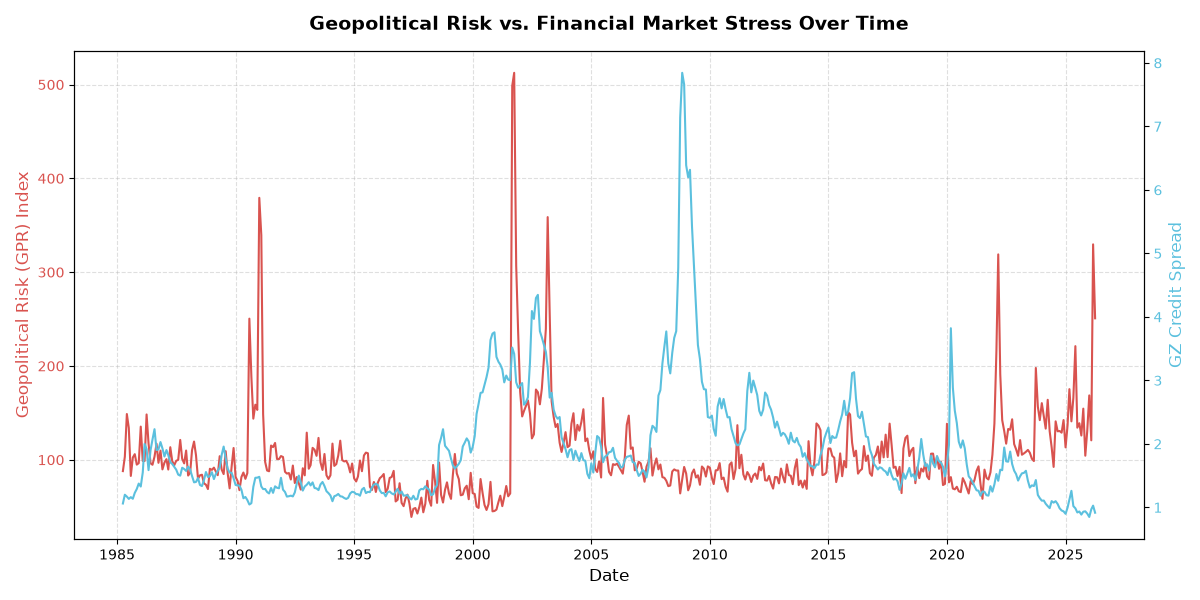

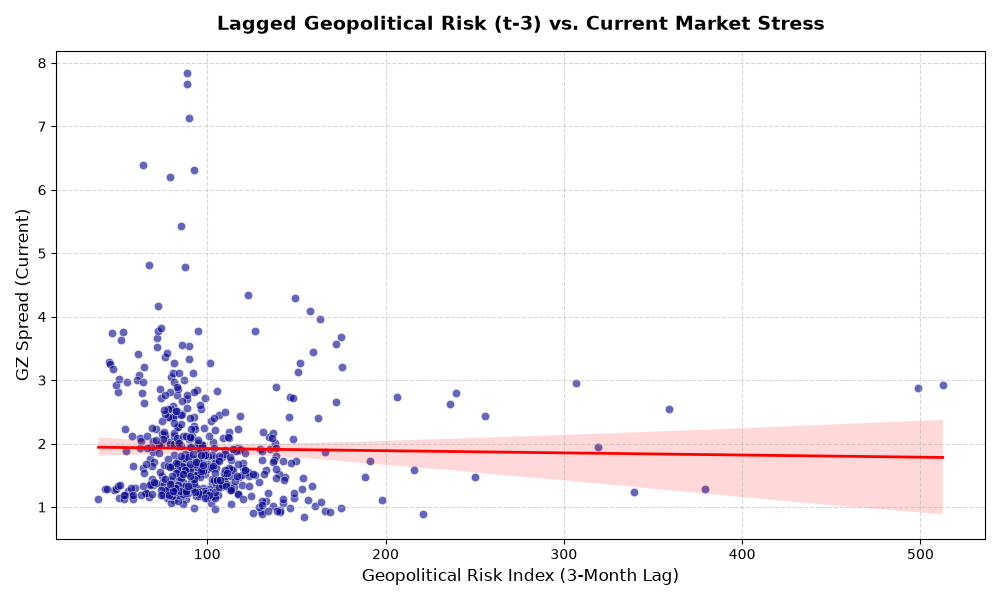

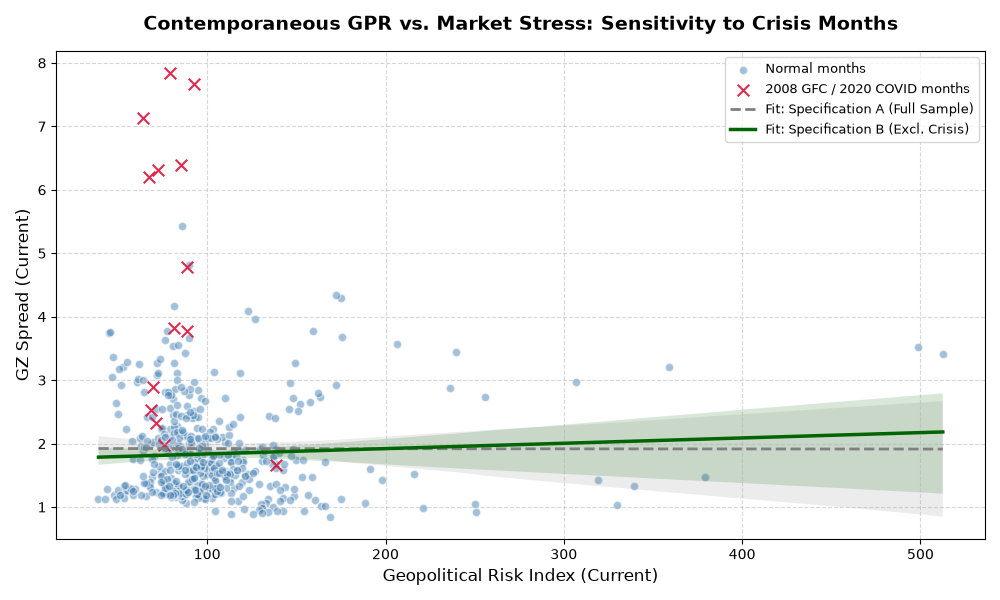

Figures saved to reports\final_project\katsuhiro-kita


[WindowsPath('C:/Projects/datascience-publicpolicy-2026/reports/final_project/katsuhiro-kita/gpr_stress_timeseries.png'),
 WindowsPath('C:/Projects/datascience-publicpolicy-2026/reports/final_project/katsuhiro-kita/gpr_lag3_stress_scatter.png'),
 WindowsPath('C:/Projects/datascience-publicpolicy-2026/reports/final_project/katsuhiro-kita/gpr_stress_crisis_sensitivity.png')]

In [3]:
import graph
graph.run()


## 4. Model Data

### **Guidance**
- Run statistical modeling (such as OLS regression) using functions in your `model.py` file.
- Specify your dependent variable and independent variables clearly.
- Print out the full model summary (e.g., coefficient table, standard errors, R-squared, p-values).
- Summarize your model findings and state whether they support your initial hypothesis.

### **Model Specifications & Interpretation**
- **Model Type:** OLS time-series regression (`statsmodels`), three regression forms, each run under **two parallel samples**, plus a supplementary event-specific correlation comparison:
    1. **Baseline (contemporaneous):** `gz_spread ~ gpr_index`
    2. **Predictive (lead-lag):** `gz_spread ~ gpr_index_lag1 + gpr_index_lag2 + gpr_index_lag3 + gz_spread_lag1`
    3. **Reverse-direction check:** `gpr_index ~ gz_spread_lag1`
- **Specification A -- Full Sample (1985-2026, N=493):** `gpr_index` has no contemporaneous relationship with `gz_spread` (R-squared = 0.000, p = 0.983). In the predictive model, `gpr_index_lag1` is small but statistically significant (coef = -0.0007, p = 0.028) -- with a **negative** sign, opposite to my hypothesis; `gpr_index_lag2` (p = 0.136) and `gpr_index_lag3` (p = 0.401) are not significant. The reverse-direction check is not significant (p = 0.866).
- **Specification B -- Excluding 2008 GFC & 2020 COVID Episodes (N=479):** Removing just 14 months around these two crises changes the picture. The contemporaneous relationship flips to a **positive** sign (coef = 0.0008), moving toward my original hypothesis, though it remains statistically insignificant (p = 0.204). The 1-month lagged effect that was significant in Specification A shrinks and is no longer significant at conventional levels (coef = -0.0004, p = 0.056). The reverse-direction coefficient also grows but stays insignificant (p = 0.177).
- **Event-Specific Analysis (Is the link conditional on a direct U.S. threat?):** As a supplementary, more descriptive check, I compared the correlation between `gpr_index` and `gz_spread` within three specific historical geopolitical episodes, rather than pooling all months together:
    - **Gulf War (1990-91, N=7):** correlation = 0.074 (near zero); regression coefficient not significant (p = 0.875). Iraq invaded Kuwait, but the U.S. homeland itself was never at risk.
    - **9/11 & War on Terror (2001-2003, N=28):** correlation = 0.248 (moderate positive); regression coefficient not significant at conventional levels given the small sample (p = 0.203). This is the one episode in the dataset where the U.S. homeland itself was directly attacked.
    - **Russia-Ukraine War (2022, N=12):** correlation = -0.448 (moderate negative); regression coefficient not significant (p = 0.144). A major war, but fought on foreign soil with the U.S. only indirectly involved.
    - **Full sample, for reference (N=493):** correlation = -0.001.
    - None of these within-event regressions reach conventional statistical significance individually -- each episode only contributes 7 to 28 monthly observations, so this comparison is descriptive/suggestive rather than a confirmed statistical result. Still, the ordering (War on Terror > Gulf War > Ukraine War) is consistent with the idea that U.S. corporate credit markets react to geopolitical risk mainly when the crisis directly threatens the U.S. homeland or its security, not simply whenever global geopolitical risk (as measured by GPR) rises.
- **Key Conclusion:** My hypothesis that geopolitical risk positively predicts *future* market stress is not supported in the full sample, and the one statistically significant result I did find (a small negative 1-month lead-lag effect) is **not robust**: it loses significance once 14 months surrounding the 2008 GFC and 2020 COVID crash are excluded (Specification B). Those two episodes are dominated by financial and public-health shocks that are largely unrelated to geopolitical risk narrowly defined, yet they combine extreme `gz_spread` values with comparatively low `gpr_index` readings -- exactly the kind of influential outliers that can flip a regression's sign and manufacture spurious significance. Beyond this robustness issue, the event-specific comparison suggests the GPR-stress relationship may not be a fixed, general one at all, but conditional on the *type* of geopolitical event: episodes that directly threaten the U.S. homeland (9/11) show a positive co-movement with U.S. corporate credit stress, while foreign wars where the U.S. is not a battlefield (Gulf War, Russia-Ukraine War) do not, and in the Ukraine case even move in the opposite direction. Taken together, I do not find robust evidence that the GPR Index is a reliable linear early-warning indicator for U.S. credit market stress in general -- if geopolitical risk matters for this market at all, it appears to matter selectively, mainly when the crisis is perceived as a direct threat to the United States itself, and any apparent aggregate effect is fragile to a handful of non-geopolitical crisis months.


In [4]:
import model
summary = model.run()



Specification A: Full Sample (1985-2026) (N=493)
--- Model 1: Contemporaneous Baseline (gz_spread ~ gpr_index) ---
                            OLS Regression Results                            
Dep. Variable:              gz_spread   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                 0.0004518
Date:                Wed, 22 Jul 2026   Prob (F-statistic):              0.983
Time:                        23:13:09   Log-Likelihood:                -658.86
No. Observations:                 493   AIC:                             1322.
Df Residuals:                     491   BIC:                             1330.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------

C:\Users\potsu\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
